In [1]:
import torch
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from PIL import Image
from transformers import BlipProcessor, BlipForConditionalGeneration
import os

processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")
model.eval()

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)

print("Model loaded successfully!")

Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

Model loaded successfully!


Load Curated Examples

In [2]:
curated_df = pd.read_csv("../data/xai_examples/curated_examples.csv")
images_dir = "../data/xai_examples"
print(curated_df.shape)
curated_df.head()

(15, 5)


,image,generated_caption,ground_truth_caption_primary,bleu_score,category
0,1187593464_ce862352c6.jpg,a dog running with a stick in its mouth,A big tan dog runs on grass with a big stick i...,1.000000,good
1,1235681222_819231767a.jpg,people sitting on benches in a public area,A person in a blue shirt sits behind two peopl...,1.000000,good
2,1000268201_693b08cb0e.jpg,a little girl in a pink dress,A child in a pink dress is climbing up a set o...,0.866878,good
3,1119418776_58e4b93eac.jpg,a dog running in a field,A black and white dog is running through the f...,0.846482,good
4,1048710776_bb5b0a5c7c.jpg,a group of people sitting on a wall,a couple of several people sitting on a ledge ...,0.759836,good


Set Up Grad-CAM Hook on Vision Encoder

In [3]:
gradients = {}
activations = {}

def save_activation(name):
    def hook(module, input, output):
        activations[name] = output
    return hook

def save_gradient(name):
    def hook(module, grad_input, grad_output):
        gradients[name] = grad_output[0]
    return hook

# Target the last layer of the vision encoder
target_layer = model.vision_model.encoder.layers[-1]
target_layer.register_forward_hook(save_activation("vision_last_layer"))
target_layer.register_full_backward_hook(save_gradient("vision_last_layer"))

print("Hooks registered on vision encoder's last layer.")

Hooks registered on vision encoder's last layer.


Function: Generate Grad-CAM Heatmap for One Image

In [7]:
def generate_gradcam(image_path):
    raw_image = Image.open(image_path).convert('RGB')
    inputs = processor(raw_image, return_tensors="pt").to(device)

    outputs = model.generate(**inputs, max_new_tokens=20)
    generated_caption = processor.decode(outputs[0], skip_special_tokens=True)

    model.zero_grad()
    pixel_values = inputs['pixel_values']
    pixel_values.requires_grad_()

    vision_outputs = model.vision_model(pixel_values=pixel_values)
    image_embeds = vision_outputs.last_hidden_state

    target = image_embeds.mean()
    target.backward()

    act = activations["vision_last_layer"][0].detach().cpu().numpy()
    grad = gradients["vision_last_layer"][0].detach().cpu().numpy()

    weights = np.mean(grad, axis=0)
    cam = np.dot(act, weights)
    cam = np.maximum(cam, 0)
    cam = cam / (cam.max() + 1e-8)

    num_patches = int(np.sqrt(cam.shape[0] - 1)) if int(np.sqrt(cam.shape[0]-1))**2 == cam.shape[0]-1 else int(np.sqrt(cam.shape[0]))
    cam_map = cam[-(num_patches**2):].reshape(num_patches, num_patches)

    cam_resized = cv2.resize(cam_map, (raw_image.width, raw_image.height))

    return raw_image, cam_resized, generated_caption

Function: Overlay Heatmap on Image

In [5]:
def overlay_heatmap(raw_image, cam_resized, alpha=0.5):
    img_np = np.array(raw_image)
    heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
    heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 1 - alpha, heatmap, alpha, 0)
    return overlay

Test On One Image

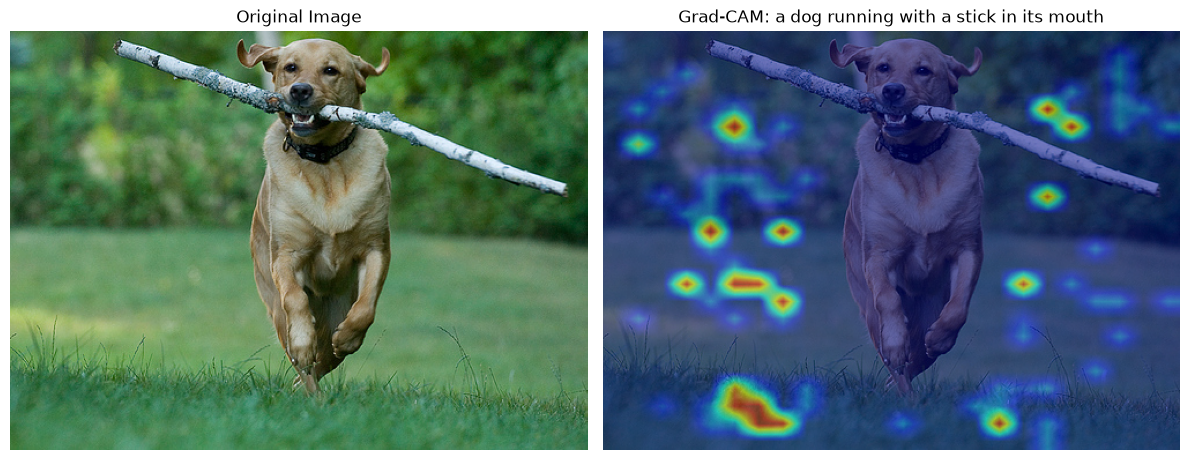

In [8]:
test_img_path = os.path.join(images_dir, curated_df['image'].iloc[0])
raw_image, cam_resized, caption = generate_gradcam(test_img_path)
overlay = overlay_heatmap(raw_image, cam_resized)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(raw_image)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(overlay)
axes[1].set_title(f"Grad-CAM: {caption}")
axes[1].axis('off')

plt.tight_layout()
plt.show()

Apply Grad-CAM To All Curated Examples

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(18, 28))
axes = axes.flatten()

for i, row in curated_df.iterrows():
    img_path = os.path.join(images_dir, row['image'])
    raw_image, cam_resized, caption = generate_gradcam(img_path)
    overlay = overlay_heatmap(raw_image, cam_resized)

    axes[i].imshow(overlay)
    axes[i].set_title(f"[{row['category']}] {caption[:35]}", fontsize=9)
    axes[i].axis('off')

plt.tight_layout()
plt.savefig("gradcam_all_examples.png")
plt.show()